In [6]:
import os
import sys
import numpy as np
from gen_graph import gen_plots

# custom imports
current_dir = os.getcwd()
parent_dir = os.path.abspath(os.path.join(current_dir, ".."))
if parent_dir not in sys.path:
    sys.path.insert(0, parent_dir)
from soft_threshold_host import train_soft
from data_proc.mock_data import gen_signal

In [7]:
N = 1000
DATA_SAMPLES = 1
time = np.linspace(0, 10 * np.pi, N, dtype=np.float32)

In [13]:
data = [gen_signal(N, time) for i in range(DATA_SAMPLES)]

noisy_audio = [i[0] for i in data]
clean_audio = [i[1] for i in data]

thresh, scale, loss_hist = train_soft(noisy_audio, clean_audio, N, lr=5e-4, BATCH_SIZE=1)


Reverse differentiation of function rev_soft_thresh_loss:
def rev_soft_thresh_loss(noisy : In[Array[float]], _dnoisy_bLLvtb : Out[Array[float]], clean : In[Array[float]], _dclean_4Aelxg : Out[Array[float]], threshold : In[float], _dthreshold_TlZQ48 : Out[float], scale : In[float], _dscale_e0oORL : Out[float], N : In[int], _dN_j8FhKf : Out[int], _dreturn_dDW8oZ : In[float]) -> void:
	_t_float_J9Nq5Y : Array[float, 561000]
	_stack_ptr_float_J9Nq5Y : int = (int)(0)
	_t_int_7FzN4k : Array[int, 153000]
	_stack_ptr_int_7FzN4k : int = (int)(0)
	_loop_var_0_yNPtzw : int
	_call_t_0_zEJrrH : int
	_call_t_2_rLNz60 : float
	_d_call_t_2_rLNz60_zCI57D : float
	_call_t_3_WxasDw : int
	_call_t_5_drUQJ3 : float
	_d_call_t_5_drUQJ3_pPGYv8 : float
	loss : float = (float)(0.0)
	_dloss_kiIqbw : float
	i : int = (int)(0)
	val : float = (float)(0.0)
	_dval_QajoEo : float
	abs_val : float = (float)(0.0)
	_dabs_val_cdx2q3 : float
	sign : float = (float)(0.0)
	_dsign_NddCd0 : float
	out_val : float = (float)(0

training...: 100%|██████████| 250/250 [00:00<00:00, 9001.50it/s]

Epoch 0 | Loss: 489.8536
Epoch 10 | Loss: 183.0196
Epoch 20 | Loss: 169.0438
Epoch 30 | Loss: 167.3917
Epoch 40 | Loss: 167.0178
Epoch 50 | Loss: 166.9110
Epoch 60 | Loss: 166.8770
Epoch 70 | Loss: 166.8656
Epoch 80 | Loss: 166.8616
Epoch 90 | Loss: 166.8603
Epoch 100 | Loss: 166.8596
Epoch 110 | Loss: 166.8596
Epoch 120 | Loss: 166.8595
Epoch 130 | Loss: 166.8593
Epoch 140 | Loss: 166.8593
Epoch 150 | Loss: 166.8594
Epoch 160 | Loss: 166.8595
Epoch 170 | Loss: 166.8595
Epoch 180 | Loss: 166.8595
Epoch 190 | Loss: 166.8595
Epoch 200 | Loss: 166.8594
Epoch 210 | Loss: 166.8595
Epoch 220 | Loss: 166.8595
Epoch 230 | Loss: 166.8595
Epoch 240 | Loss: 166.8595


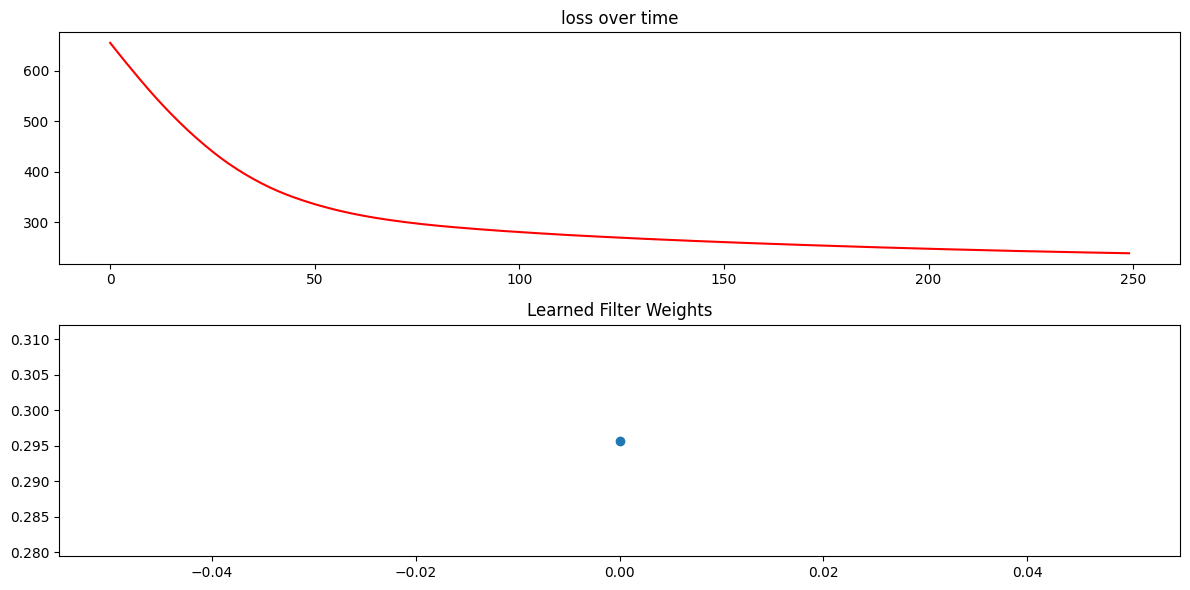

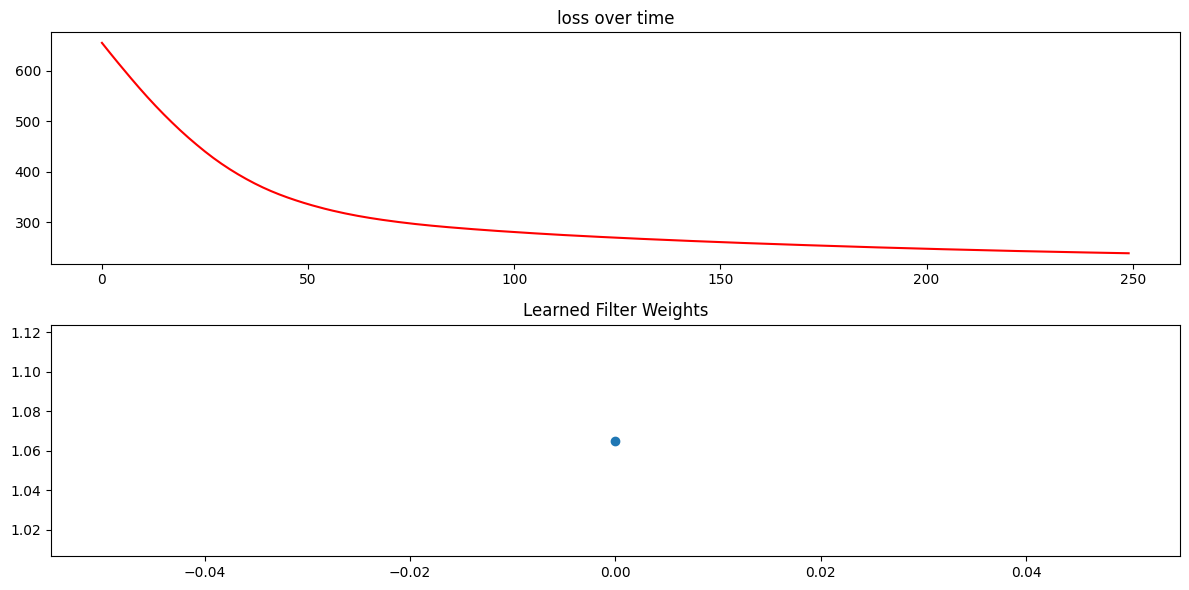

In [9]:
gen_plots(thresh, loss_hist)
gen_plots(scale, loss_hist)

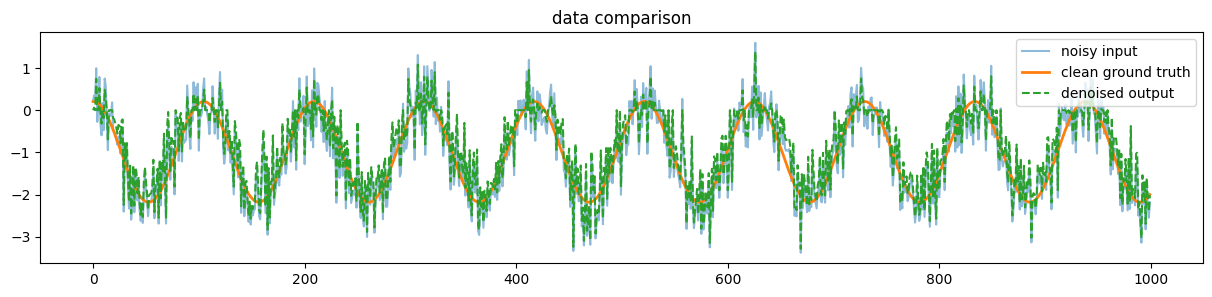

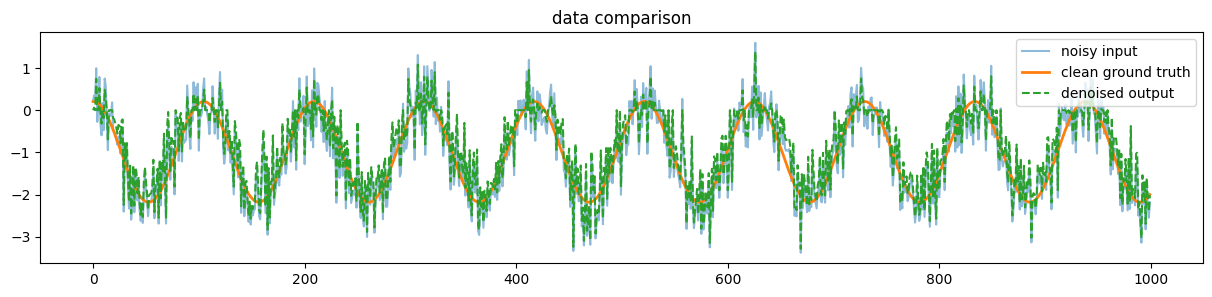

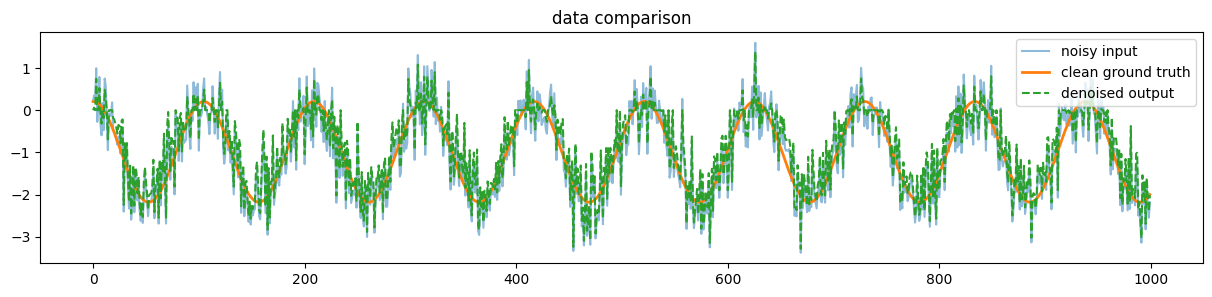

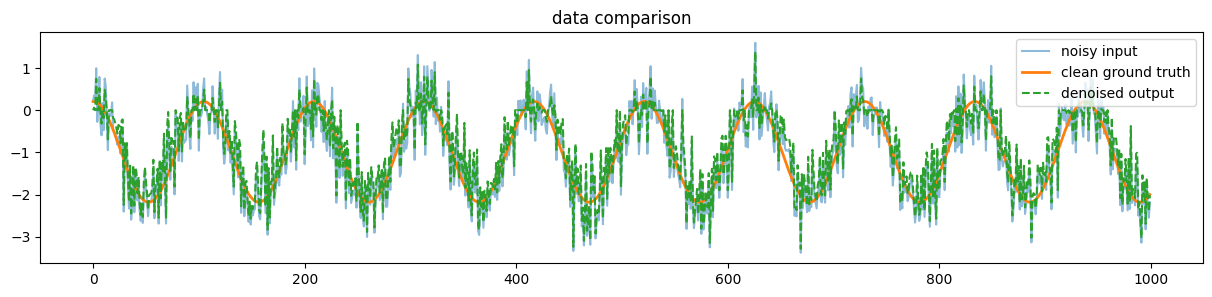

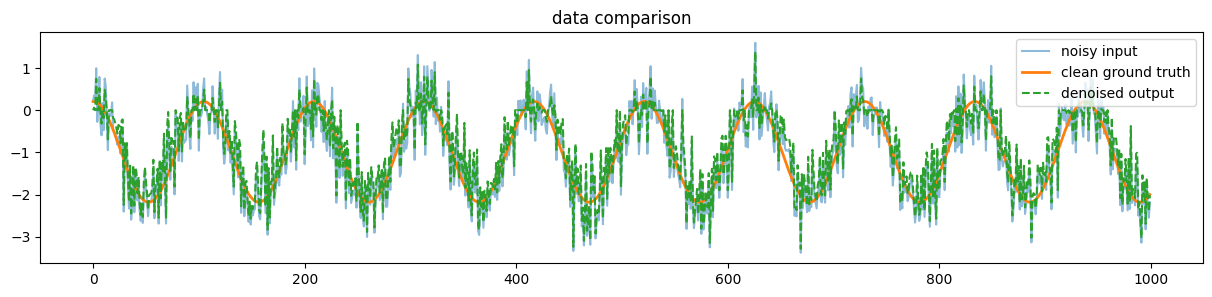

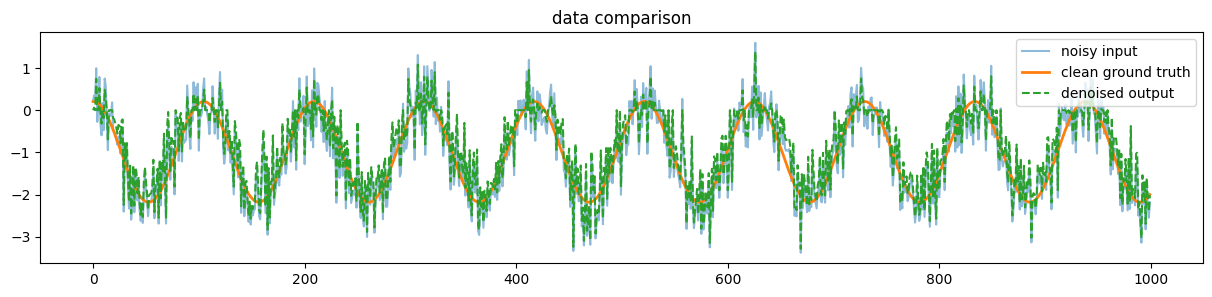

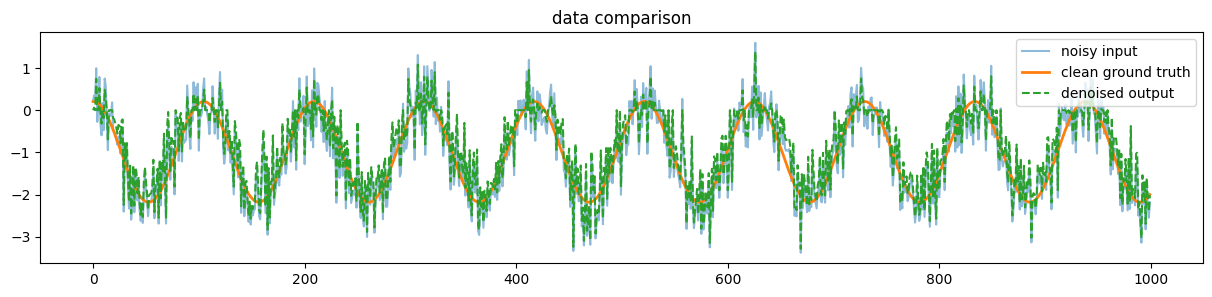

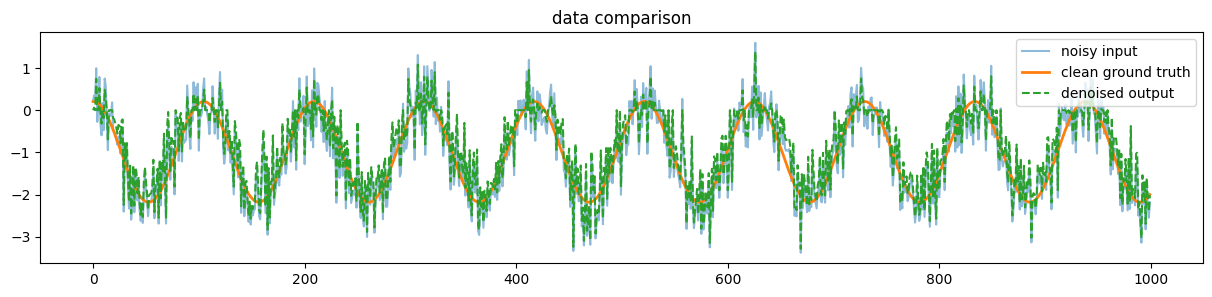

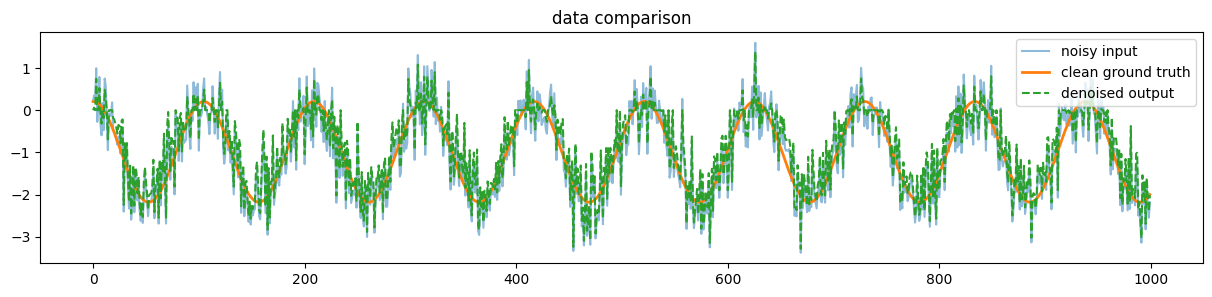

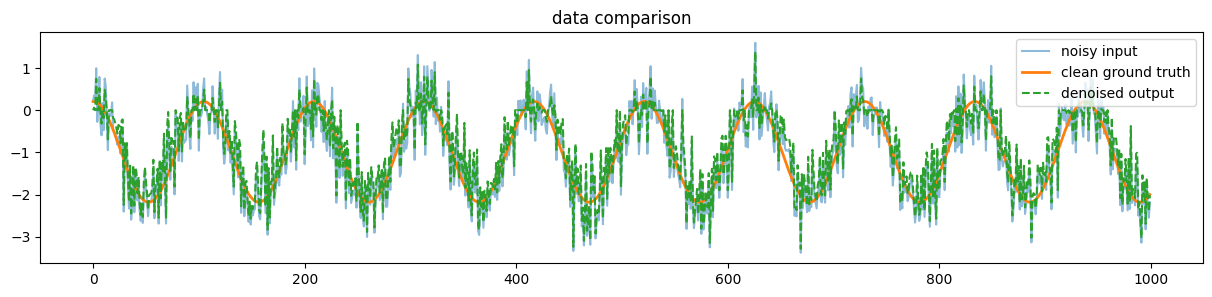

In [10]:
# peak to see on some samples
import matplotlib.pyplot as plt
import numpy as np

def peak_sample_perf(noisy_sample, clean_sample, thresh, scale):
    plt.figure(figsize=(15, 3))
    # 1. Get the absolute value and the sign of the noisy array
    abs_audio = np.abs(noisy_sample)
    sign_audio = np.sign(noisy_sample)

    # 2. Find where the audio is louder than the threshold
    gate_mask = abs_audio > thresh

    # 3. Apply the math: sign * (abs - threshold) * scale
    # We multiply by gate_mask so anything below the threshold instantly becomes 0.0
    denoised_audio = gate_mask * sign_audio * (abs_audio - thresh) * scale

    # (Optional) Ensure audio doesn't clip
    # denoised_audio = np.clip(denoised_audio, -1.0, 1.0)

    plt.title("data comparison")
    plt.plot(noisy_sample, label="noisy input", alpha=0.5)
    plt.plot(clean_sample, label="clean ground truth", linewidth=2)
    plt.plot(denoised_audio, label="denoised output", linestyle='--')
    plt.legend()

    plt.show()

for i in range(10):
    idx = np.random.randint(0, len(noisy_audio))

    noisy_sample = noisy_audio[idx]
    clean_sample = clean_audio[idx]

    peak_sample_perf(noisy_sample, clean_sample, thresh, scale)